# Phase 1 — Tabular data: bivariate relationships (Solution)

**Mục tiêu:** từ bảng 2 chiều (cột X vs cột Y, có thể có nhóm `hue`), khảo sát quan hệ: tuyến tính / phân tán / khác biệt nhóm.

Dữ liệu: `gapminder.csv` (tập trung 2007 để giảm overlap).


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "gapminder.csv").exists():
            return p
    raise FileNotFoundError(
        "Cannot locate data/gapminder.csv from current working directory"
    )

root = resolve_repo_root()


sns.set_theme(style="whitegrid")
df = pd.read_csv(root / "data" / "gapminder.csv")
d2007 = df[df["year"] == 2007].copy()
d2007.head()


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32


## 1) Scatter: hai cột số + mã hoá nhóm


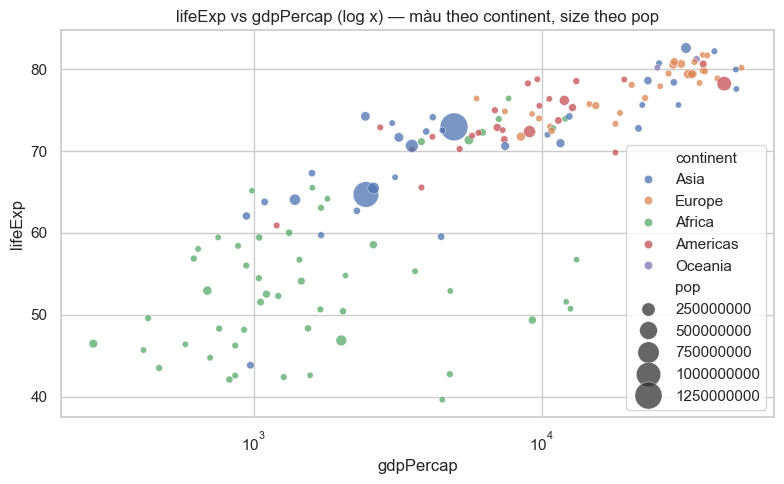

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=d2007,
    x="gdpPercap",
    y="lifeExp",
    hue="continent",
    size="pop",
    sizes=(20, 400),
    alpha=0.75,
    ax=ax,
)
ax.set_xscale("log")
ax.set_title("lifeExp vs gdpPercap (log x) — màu theo continent, size theo pop")
plt.tight_layout()
plt.show()


## 2) Regression view (cảnh báo: không phải causal)


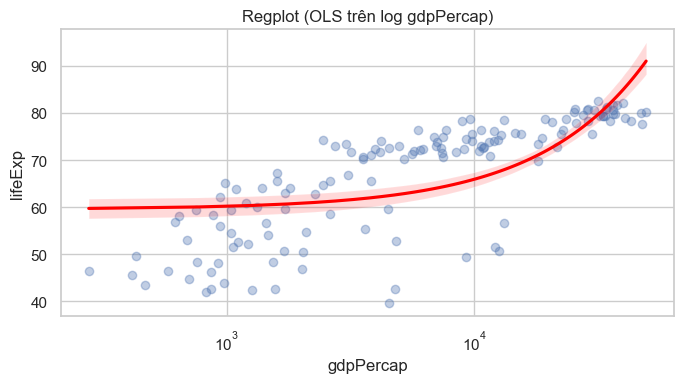

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.regplot(
    data=d2007,
    x="gdpPercap",
    y="lifeExp",
    scatter_kws={"alpha": 0.35},
    line_kws={"color": "red"},
    x_jitter=0,
    ax=ax,
)
ax.set_xscale("log")
ax.set_title("Regplot (OLS trên log gdpPercap)")
plt.tight_layout()
plt.show()


## 3) So sánh phân phối theo nhóm (một số vs một nominal)


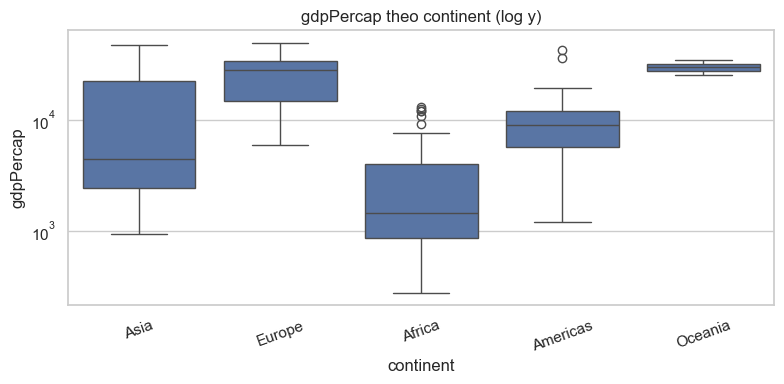

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=d2007, x="continent", y="gdpPercap", ax=ax)
ax.set_yscale("log")
ax.tick_params(axis="x", rotation=20)
ax.set_title("gdpPercap theo continent (log y)")
plt.tight_layout()
plt.show()


## 4) Correlation heatmap trên numeric-only slice


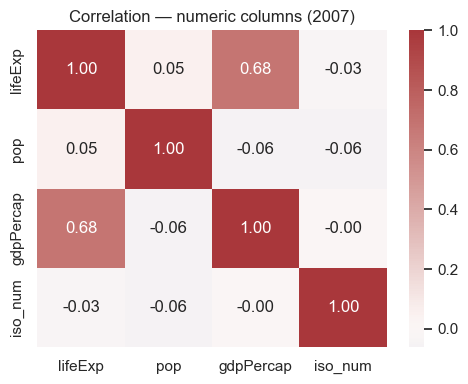

In [5]:
import numpy as np

num = d2007.select_dtypes(include=[np.number]).drop(columns=["year"], errors="ignore")
cm = num.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation — numeric columns (2007)")
plt.tight_layout()
plt.show()


## Reflection

- Correlation chỉ đo quan hệ tuyến tính — bạn sẽ kiểm chứng non-linear bằng chart nào?
- Giải thích vì sao `gdpPercap` nên log-scale khi scatter với `lifeExp`.
- Một cảnh báo khi đọc regression line trên dữ liệu quan sát (không phải thí nghiệm).


## Legacy add-on (tach tu `legacy_chapter_aligned/solution.executed.ipynb`)

Phan bo sung nay duoc ghep lai tu notebook cu de giu noi dung theo giao trinh, nhung da map vao track tabular hien tai.

### Imported section: ## 3) Visualizing amounts
Mục tiêu: biểu diễn lượng tuyệt đối bằng bar/dot.

## 3) Visualizing amounts
Mục tiêu: biểu diễn lượng tuyệt đối bằng bar/dot.

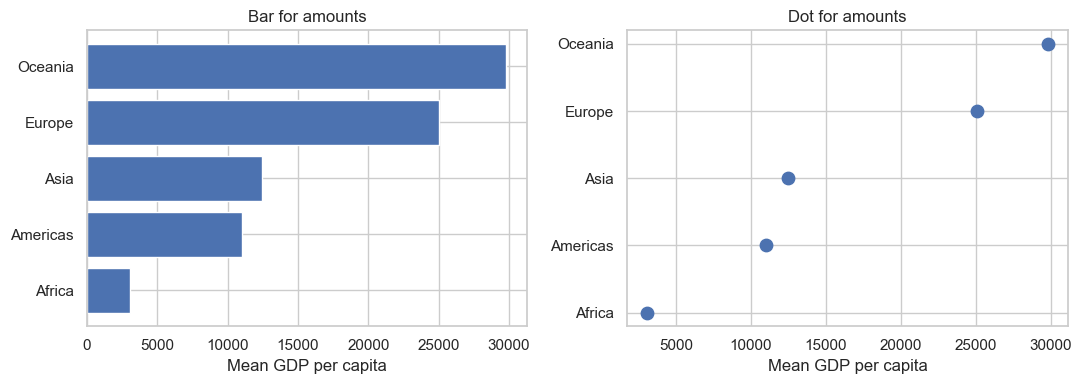

In [6]:
amt = df[df["year"]==2007].groupby("continent", as_index=False).agg(gdp=("gdpPercap","mean"))
amt = amt.sort_values("gdp")

fig, axes = plt.subplots(1,2, figsize=(11,4))
axes[0].barh(amt["continent"], amt["gdp"])
axes[0].set_title("Bar for amounts")
axes[0].set_xlabel("Mean GDP per capita")

axes[1].scatter(amt["gdp"], amt["continent"], s=80)
axes[1].set_title("Dot for amounts")
axes[1].set_xlabel("Mean GDP per capita")
plt.tight_layout(); plt.show()

### Imported section: ## 7) Visualizing associations
Mục tiêu: scatter + correlation.

## 7) Visualizing associations
Mục tiêu: scatter + correlation.

Correlation:
            gdpPercap  lifeExp    pop
gdpPercap      1.000    0.679 -0.056
lifeExp        0.679    1.000  0.048
pop           -0.056    0.048  1.000


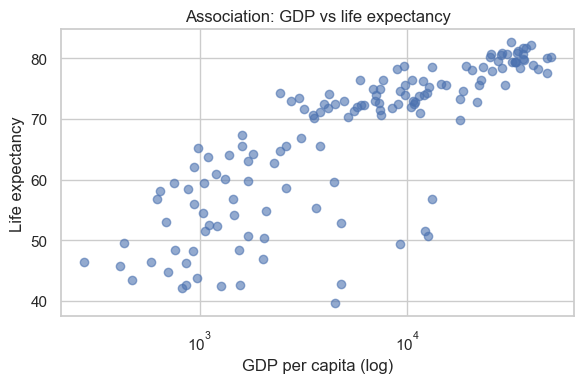

In [7]:
assoc = d2007[["gdpPercap", "lifeExp", "pop"]].copy()
print("Correlation:\n", assoc.corr(numeric_only=True).round(3))

plt.figure(figsize=(6,4))
plt.scatter(assoc["gdpPercap"], assoc["lifeExp"], alpha=0.6)
plt.xscale("log")
plt.xlabel("GDP per capita (log)")
plt.ylabel("Life expectancy")
plt.title("Association: GDP vs life expectancy")
plt.tight_layout(); plt.show()